# Speed comparision at x86-64 and ARMv8 platform

The Python code in this notebook will load the simulation results stored in the `statistics` folder and will generate a speed comparision diagram for model 1a (exponential distribution) shown in the report.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## Load and process data

In [13]:
# AMD Ryzen 9 3900XT /  Raspberry Pi 4B
data=[
    {"name": "Exponential distribution", "file_ryzen": "statistics/results1Exp.txt", "file_raspi": "statistics/results1Exp-raspberrypi.txt"},
    {"name": "Log-normal distribution", "file_ryzen": "statistics/results1Log.txt", "file_raspi": "statistics/results1Log-raspberrypi.txt"},
    {"name": "Triangular distribution", "file_ryzen": "statistics/results1Triangular.txt", "file_raspi": "statistics/results1Triangular-raspberrypi.txt"},
]

for rec in data:
    rec["df_ryzen"] = pd.read_csv(rec["file_ryzen"], header=None, names=["rng_mode", "n", "mean", "std", "delta2", "time"], sep="\t") # type: ignore
    rec["df_raspi"] = pd.read_csv(rec["file_raspi"], header=None, names=["rng_mode", "n", "mean", "std", "delta2", "time"], sep="\t") # type: ignore

generators = list(set(data[0]["df_ryzen"]["rng_mode"].drop_duplicates().tolist()) & set(data[0]["df_raspi"]["rng_mode"].drop_duplicates().tolist())) # type: ignore

In [14]:
for rec in data:
    # Mean value per generator (100 runs were done per generator)
    times_ryzen = []
    times_raspi = []
    for generator in generators:
        times_ryzen.append(rec["df_ryzen"][rec["df_ryzen"]["rng_mode"] == generator]["time"].mean()) # type: ignore
        times_raspi.append(rec["df_raspi"][rec["df_raspi"]["rng_mode"] == generator]["time"].mean()) # type: ignore

    # Data frame consisting of generator name and time
    df_times_ryzen = pd.DataFrame({"generator": generators, "time_ryzen": times_ryzen}, index=generators)
    df_times_raspi = pd.DataFrame({"generator": generators, "time_raspi": times_raspi}, index=generators)
    rec["df_times_ryzen"] = df_times_ryzen # type: ignore
    rec["df_times_raspi"] = df_times_raspi # type: ignore

    # Sorted data frame
    df_times_ryzen_sorted = df_times_ryzen.sort_values("time_ryzen", ascending=True).reset_index(drop=True)
    df_times_raspi_sorted = df_times_raspi.sort_values("time_raspi", ascending=True).reset_index(drop=True)

    # Get fastest time for x86-64 and ARMv8 (to display percent values in diagram)
    rec["fastest_time_ryzen"] = df_times_ryzen_sorted.iloc[0]["time_ryzen"]
    rec["fastest_time_raspi"] = df_times_raspi_sorted.iloc[0]["time_raspi"]

    # Add index
    df_times_ryzen_sorted["rank_ryzen"] = df_times_ryzen_sorted.index + 1
    df_times_raspi_sorted["rank_raspi"] = df_times_raspi_sorted.index + 1

    # Merge data for x86-64 and ARMv8
    rec["df_merged"] = pd.merge(df_times_ryzen_sorted[["generator", "time_ryzen", "rank_ryzen"]], df_times_raspi_sorted[["generator", "time_raspi", "rank_raspi"]], on="generator") # type: ignore

In [15]:
sum_times_ryzen = data[0]["df_times_ryzen"].copy()["time_ryzen"]  # type: ignore
for i in range(1, len(data)):
    sum_times_ryzen = sum_times_ryzen + data[i]["df_times_ryzen"]["time_ryzen"]  # type: ignore

sum_times_raspi = data[0]["df_times_raspi"].copy()["time_raspi"]  # type: ignore
for i in range(1, len(data)):
    sum_times_raspi = sum_times_raspi + data[i]["df_times_raspi"]["time_raspi"]  # type: ignore

sum_times_ryzen = pd.DataFrame({"generator": generators, "time_ryzen": sum_times_ryzen}, index=generators) # type: ignore
sum_times_raspi = pd.DataFrame({"generator": generators, "time_raspi": sum_times_raspi}, index=generators) # type: ignore

In [16]:
# Sorted data frame
sum_times_ryzen_sorted = sum_times_ryzen.sort_values("time_ryzen", ascending=True).reset_index(drop=True)
sum_times_raspi_sorted = sum_times_raspi.sort_values("time_raspi", ascending=True).reset_index(drop=True)

# Get fastest time for x86-64 and ARMv8 (to display percent values in diagram)
fastest_sum_time_ryzen = sum_times_ryzen_sorted.iloc[0]["time_ryzen"]
fastest_sum_time_raspi = sum_times_raspi_sorted.iloc[0]["time_raspi"]

# Add index
sum_times_ryzen_sorted["rank_ryzen"] = sum_times_ryzen_sorted.index + 1
sum_times_raspi_sorted["rank_raspi"] = sum_times_raspi_sorted.index + 1

# Merge data for x86-64 and ARMv8
sum_merged = pd.merge(sum_times_ryzen_sorted[["generator", "time_ryzen", "rank_ryzen"]], sum_times_raspi_sorted[["generator", "time_raspi", "rank_raspi"]], on="generator")  # type: ignore

# Data frame for average of all distributions
average = {"df_merged": sum_merged, "fastest_time_ryzen": fastest_sum_time_ryzen, "fastest_time_raspi": fastest_sum_time_raspi, "name": "Average of all distributions"}

### Colors for generator types

In [17]:
def color_from_name(name):
    if name in ['SecureRandom', 'ISAAC']:
        return 'blue'
    if name in ['Drand48', 'Drand48Mix']:
        return 'red'
    return 'black'

is_reflection=["XoRoShiRo256++", "L64X128Mix", "L64X128**", "L64X256Mix", "L64X1024Mix", "L128X128Mix", "L128X256Mix", "L128X1024Mix"]

def gen_full_name(generator):
    if generator=="ThreadLocalRandomSlow":
        return "ThreadLocalRandom.current() (**)"
    if generator in is_reflection:
        return generator+" (*)"
    return generator

## Generate diagram

In [18]:
def build_diagram(df_merged, fastest_time_ryzen, fastest_time_raspi, title):
    # For the diagram: left x position = 0, right x position = 1
    x_left, x_right = 0, 1

    fig, ax = plt.subplots(figsize=(6, 8))

    for _, row in df_merged.iterrows():
        # Get data for generator
        time_left = round(row["time_ryzen"] / fastest_time_ryzen * 100)
        time_right = round(row["time_raspi"] / fastest_time_raspi * 100)
        y_left = row["rank_ryzen"]
        y_right = row["rank_raspi"]
        gen = row["generator"]

        # Average rank (for color of connection line)
        average_rank = (row["rank_raspi"] + row["rank_ryzen"]) / (len(df_merged) * 2)
        if average_rank < 0.25:
            color = "green"
        elif average_rank < 0.50:
            color = "gray"
        elif average_rank < 0.75:
            color = "orange"
        else:
            color = "red"

        # Connection line
        verts = [(x_left, y_left), (0.5, y_left), (0.5, y_right), (x_right, y_right)]
        codes = [patches.Path.MOVETO, patches.Path.CURVE4, patches.Path.CURVE4, patches.Path.CURVE4]  # pyright: ignore[reportAttributeAccessIssue]
        path = patches.Path(verts, codes)  # pyright: ignore[reportAttributeAccessIssue]
        patch = patches.PathPatch(path, edgecolor=color, facecolor="none", alpha=0.7)
        ax.add_patch(patch)

        # Points
        # ax.scatter([x_left], [y_left], color="blue", s=30)
        # ax.scatter([x_right], [y_right], color="red", s=30)

        # Labels
        ax.text(x_left - 0.02, y_left, gen_full_name(gen) + " (" + str(time_left) + "%)", ha="right", va="center", color=color_from_name(gen))
        ax.text(x_right + 0.02, y_right, gen_full_name(gen) + " (" + str(time_right) + "%)", ha="left", va="center", color=color_from_name(gen))

    # Setup axis
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(0.5, len(df_merged) + 0.5)
    ax.invert_yaxis()  # Rang 1 at top

    ax.set_xticks([x_left, x_right])
    ax.set_xticklabels(["Ryzen 9 3900XT\n(x86-64)", "Raspberry Pi 4B\n(ARMv8)"], fontsize=12)

    ax.set_yticks([])  # no y axis labels

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.set_title(title)

    return fig


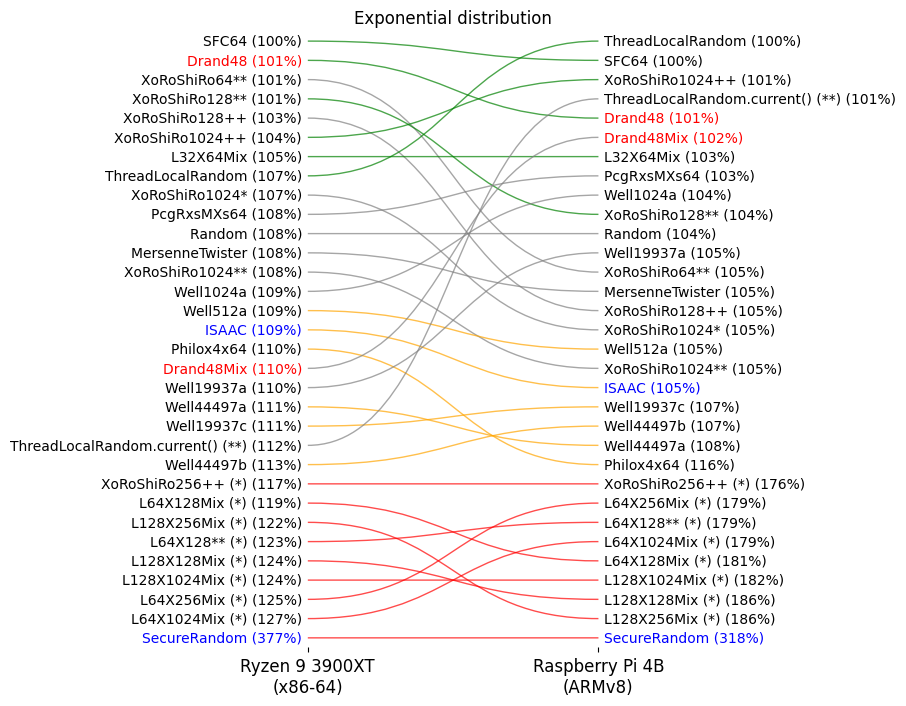

In [19]:
rec = data[0]
fig = build_diagram(rec["df_merged"], rec["fastest_time_ryzen"], rec["fastest_time_raspi"], rec["name"])

# fig.savefig("plot1platforms-Exp.png", format="png", bbox_inches='tight', pad_inches=0)

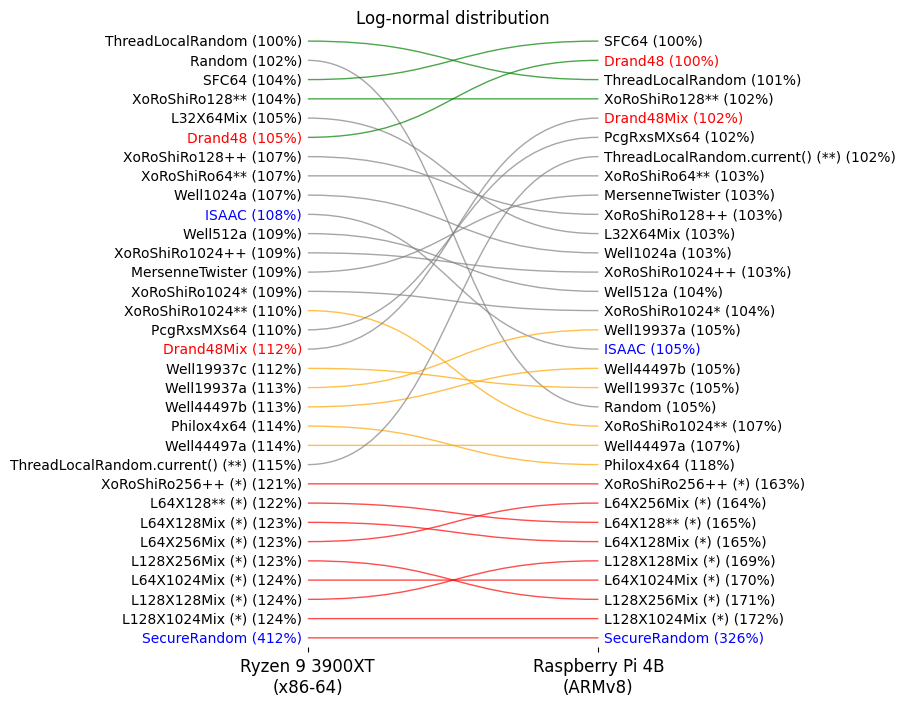

In [ ]:
rec = data[1]
fig = build_diagram(rec["df_merged"], rec["fastest_time_ryzen"], rec["fastest_time_raspi"], rec["name"])

# fig.savefig("plot1platforms-Log.png", format="png", bbox_inches='tight', pad_inches=0)

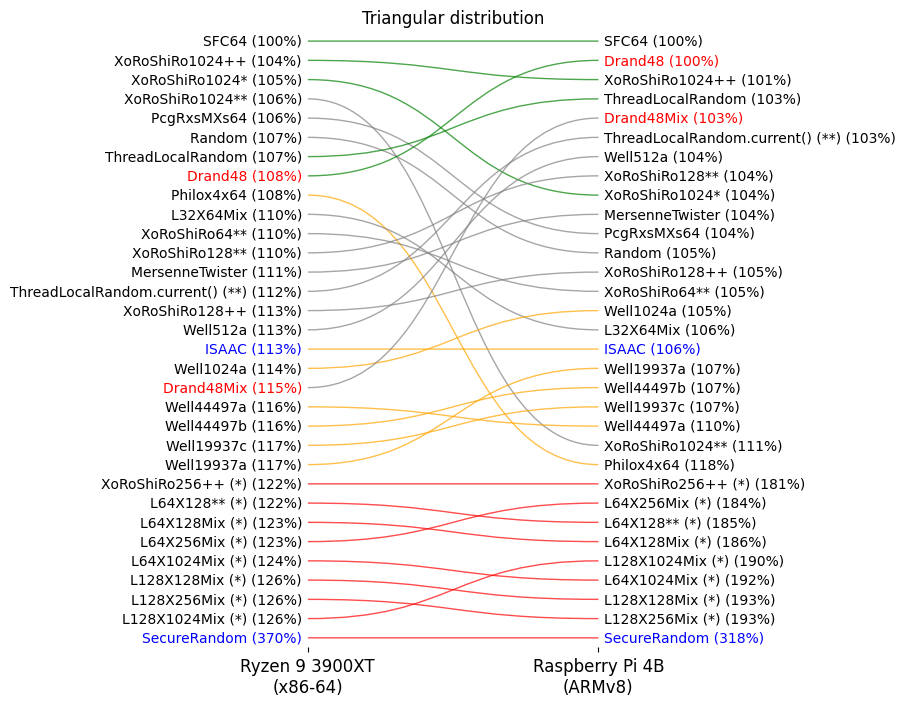

In [21]:
rec = data[2]
fig = build_diagram(rec["df_merged"], rec["fastest_time_ryzen"], rec["fastest_time_raspi"], rec["name"])

# fig.savefig("plot1platforms-Triangular.png", format="png", bbox_inches='tight', pad_inches=0)

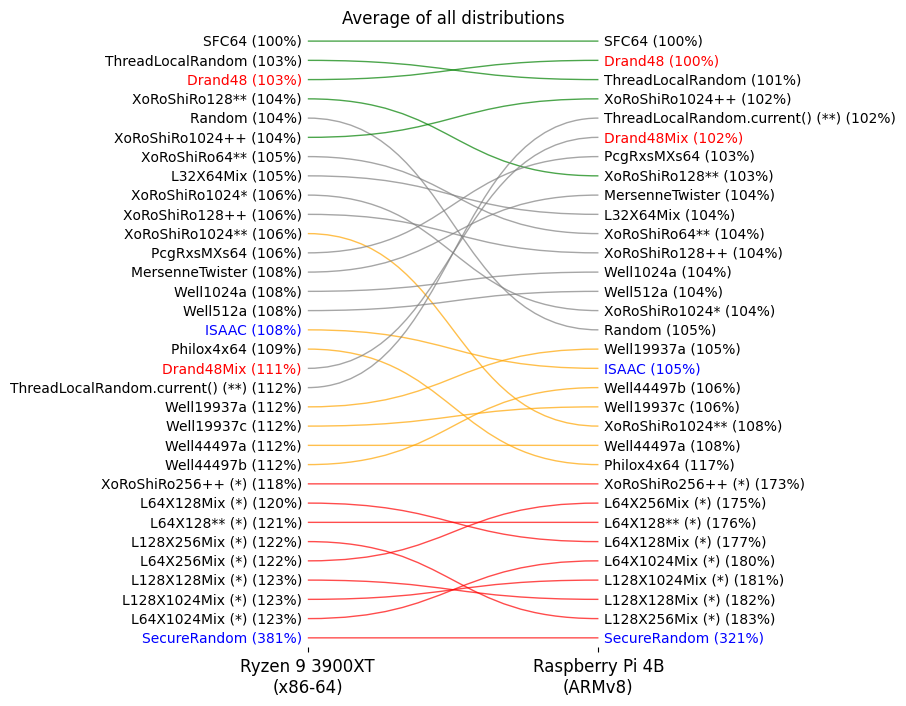

In [22]:
rec = average
fig = build_diagram(rec["df_merged"], rec["fastest_time_ryzen"], rec["fastest_time_raspi"], rec["name"]) # type: ignore

# fig.savefig("plot1platforms-Combined.png", format="png", bbox_inches='tight', pad_inches=0)

# fig.savefig("PRNG-DES-Benchmarks-Figures-plot1platforms.pdf", format="pdf", bbox_inches='tight', pad_inches=0)